# Tarea 2 — Proyecto de Aprendizaje Automático
### Universidad Cenfotec — Aprendizaje Automático
### Scikit-Learn | Sin PySpark

**Desarrollo realizado en esta versión:**
- Parte I: Heart Disease Dataset — clasificación binaria.
- Parte II: se conserva sin resolver y sin modificaciones.

> Propuesta de solución elaborada siguiendo el enunciado y los ejemplos vistos en clase.


In [1]:
# ── Instalación (Google Colab) ────────────────────────────────────────────────
# !pip install scikit-learn matplotlib seaborn scipy pandas numpy -q

import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# ── Sklearn: preprocesamiento ─────────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.base import clone

# ── Sklearn: clasificación ────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# ── Sklearn: clustering ───────────────────────────────────────────────────────
# Se mantienen estos imports porque la Parte II original los utiliza,
# pero en esta versión no se analiza ni se ejecuta esa parte.
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Sklearn: métricas ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
print('Entorno listo.')


Matplotlib is building the font cache; this may take a moment.


Entorno listo.


## 📋 Alcance de esta propuesta

Se completan únicamente las celdas correspondientes a la **Parte I — Clasificación: Heart Disease**.

**Reglas aplicadas:** Scikit-Learn | sin PySpark | `random_state=42` | split estratificado | `cross_val_score` para K-Fold.

La Parte II se mantiene exactamente como estaba en el notebook entregado.

---


## 0.2. Generar / cargar los datasets

Si tienes los CSV, descomenta la carga. Si no, el bloque siguiente los genera automáticamente.

URL: https://archive.ics.uci.edu/dataset/45/heart+disease
URL: https://www.kaggle.com/datasets/shwetabh123/mall-customers

In [2]:
# ── Carga del dataset de Heart Disease ────────────────────────────────────────
# El archivo debe estar en la misma carpeta del notebook, como pide la entrega.
df_heart_raw = pd.read_csv('heart_disease.csv')

# El CSV suministrado conserva algunas codificaciones originales de Cleveland.
# Las adaptamos al formato binario/categórico descrito en el enunciado del proyecto.
if not set(df_heart_raw['target'].dropna().unique()).issubset({0, 1}):
    df_heart_raw['target'] = (df_heart_raw['target'] > 0).astype(int)

if set(df_heart_raw['cp'].dropna().unique()) == {1.0, 2.0, 3.0, 4.0}:
    df_heart_raw['cp'] = df_heart_raw['cp'] - 1

if set(df_heart_raw['slope'].dropna().unique()) == {1.0, 2.0, 3.0}:
    df_heart_raw['slope'] = df_heart_raw['slope'] - 1

if set(df_heart_raw['thal'].dropna().unique()).issubset({3.0, 6.0, 7.0}):
    df_heart_raw['thal'] = df_heart_raw['thal'].map({3.0: 1.0, 6.0: 2.0, 7.0: 3.0})

print(f'Heart Disease: {df_heart_raw.shape} | target: {df_heart_raw.target.value_counts().sort_index().to_dict()}')

# La carga de Mall Customers pertenece a la Parte II y no se modifica aquí.


Heart Disease: (303, 14) | target: {0: 164, 1: 139}


---
# PARTE I — CLASIFICACIÓN: HEART DISEASE

## 1. Carga y exploración inicial

In [3]:
# Copia de trabajo para la Parte I.
df_heart = df_heart_raw.copy()

# Variables continuas que utilizaremos en KDE y en el análisis de outliers.
CONTINUOUS_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
FEATURE_COLS_ALL = [c for c in df_heart.columns if c != 'target']

print(f'Filas: {df_heart.shape[0]}  Columnas: {df_heart.shape[1]}')
display(df_heart.head(10))

print('\nTipos de datos:')
print(df_heart.dtypes)

print('\nNulos por columna:')
print(df_heart.isnull().sum())

# Revisión de ceros en variables clínicas continuas.
print('\nCeros en variables continuas:')
print((df_heart[CONTINUOUS_COLS] == 0).sum())

print('\nInterpretación de ceros:')
print('- age, trestbps, chol y thalach no deberían ser 0 en un paciente; en este archivo no presentan ceros.')
print('- oldpeak=0 sí puede ser válido porque representa ausencia de depresión ST.')
print('- Los ceros de variables binarias/categóricas (sex, fbs, restecg, exang, ca y target) representan categorías válidas.')


Filas: 303  Columnas: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,0.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67.0,1.0,3.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,67.0,1.0,3.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,1.0,2.0,3.0,1
3,37.0,1.0,2.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,1.0,0
4,41.0,0.0,1.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,0.0,0.0,1.0,0
5,56.0,1.0,1.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,0.0,0.0,1.0,0
6,62.0,0.0,3.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,2.0,2.0,1.0,1
7,57.0,0.0,3.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,0.0,0.0,1.0,0
8,63.0,1.0,3.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,1.0,1.0,3.0,1
9,53.0,1.0,3.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,2.0,0.0,3.0,1



Tipos de datos:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Ceros en variables continuas:
age          0
trestbps     0
chol         0
thalach      0
oldpeak     99
dtype: int64

Interpretación de ceros:
- age, trestbps, chol y thalach no deberían ser 0 en un paciente; en este archivo no presentan ceros.
- oldpeak=0 sí puede ser válido porque representa ausencia de depresión ST.
- Los ceros de variables binarias/categóricas (sex, fbs, restecg, exang, ca y target) representan categorías válidas.


## 2. EDA

In [4]:
# TODO 2: Estadísticas descriptivas con describe(include='all').
estadisticas = df_heart.describe(include='all').T.round(3)
display(estadisticas)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.680,0.467,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158,0.960,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.149,0.356,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990,0.995,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.327,0.470,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2


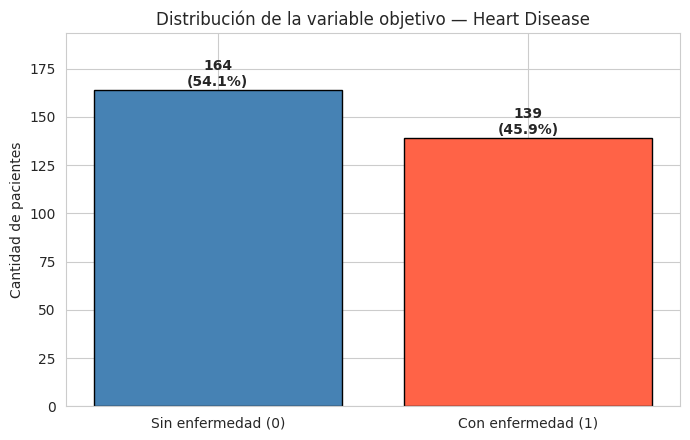

In [5]:
# TODO 3: Distribución del target con barras y porcentajes.
counts = df_heart['target'].value_counts().sort_index()
labels = ['Sin enfermedad (0)', 'Con enfermedad (1)']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='black')

for bar, value in zip(bars, counts.values):
    pct = 100 * value / len(df_heart)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{value}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Distribución de la variable objetivo — Heart Disease')
ax.set_ylabel('Cantidad de pacientes')
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()


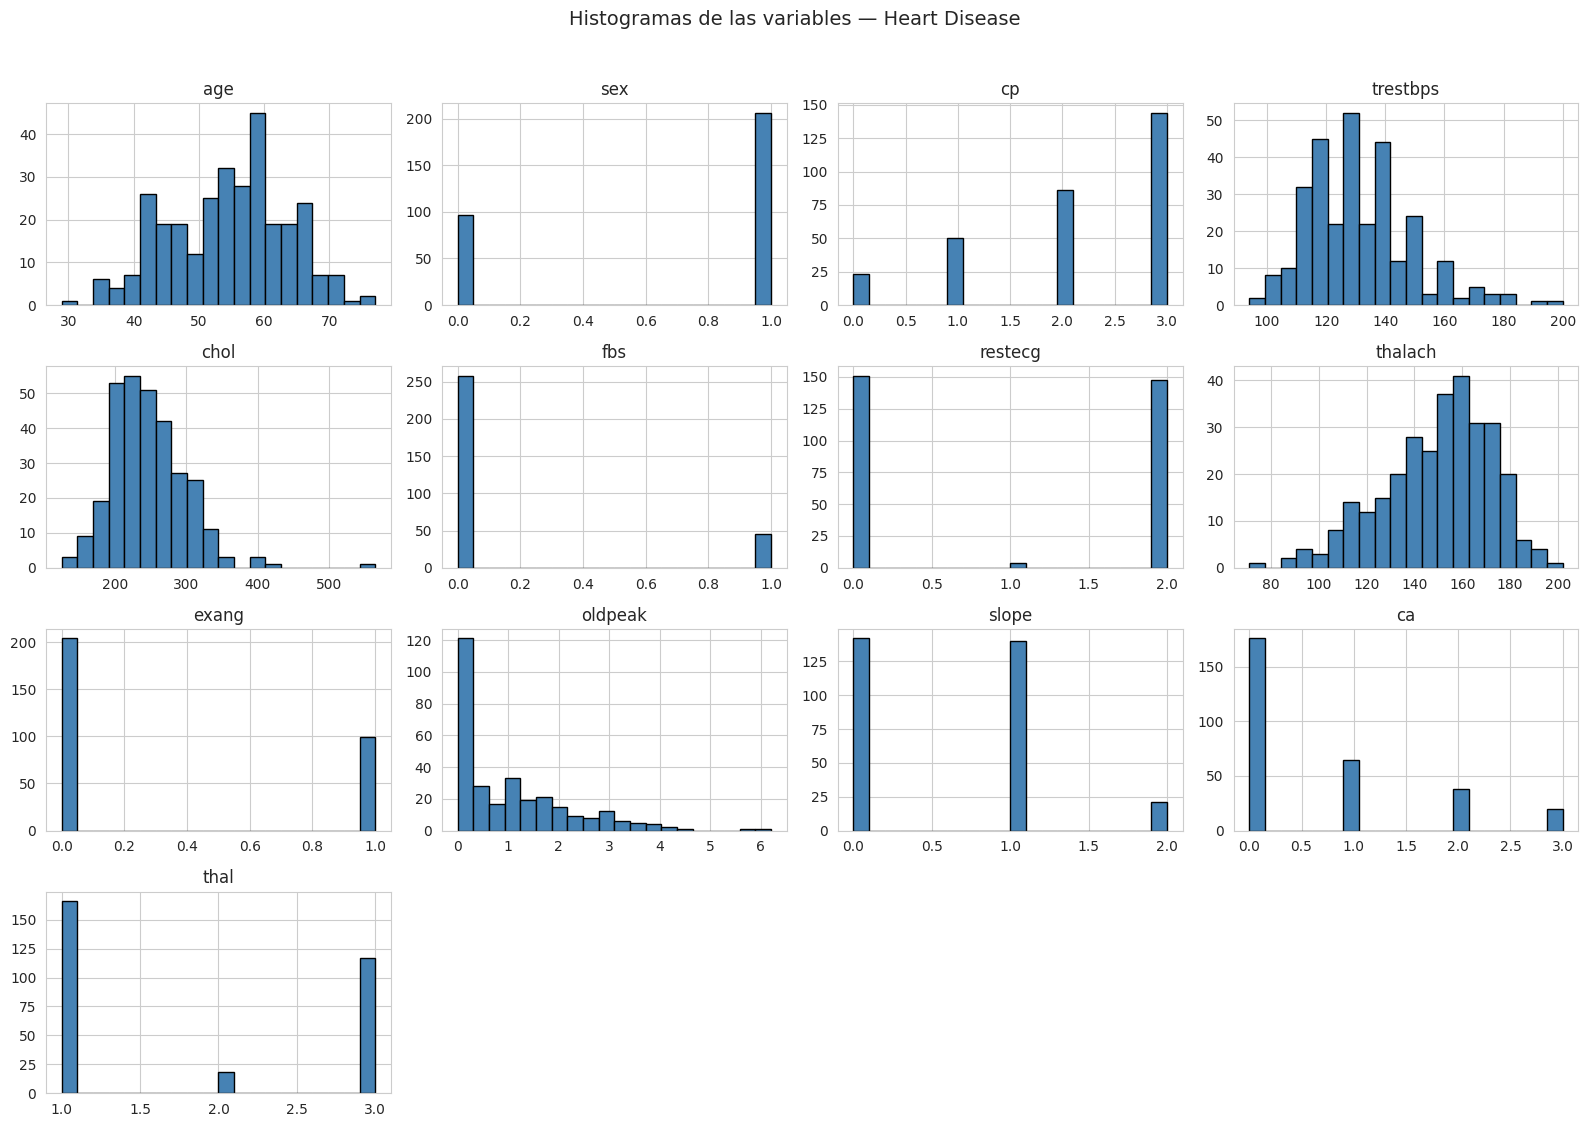

In [6]:
# TODO 4: Histogramas de todas las variables numéricas predictoras.
# Se excluye target porque ya fue analizado con un gráfico de barras.
hist_cols = [c for c in df_heart.columns if c != 'target']
df_heart[hist_cols].hist(bins=20, figsize=(16, 11), color='steelblue', edgecolor='black')
plt.suptitle('Histogramas de las variables — Heart Disease', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


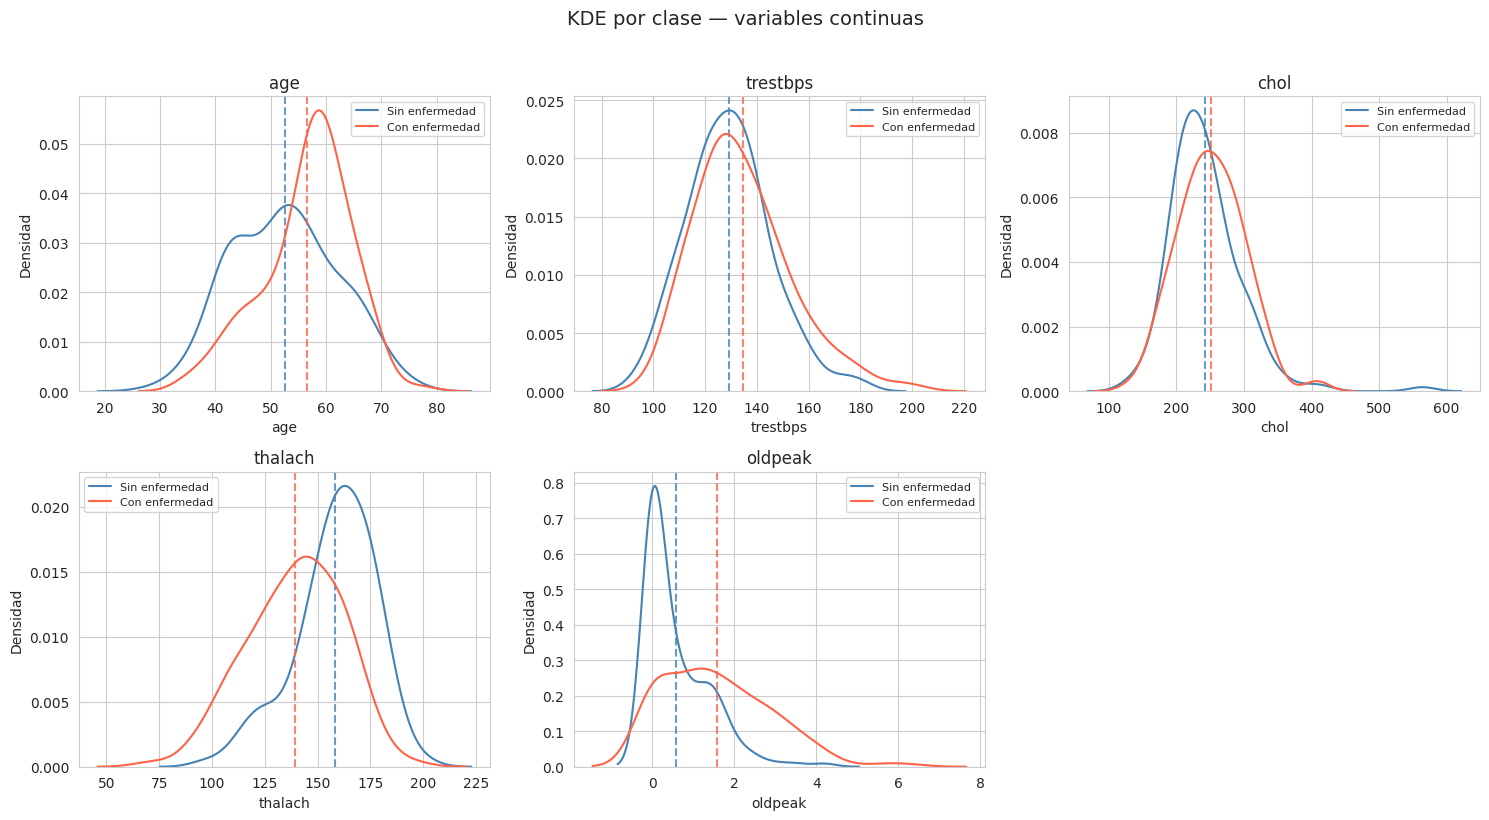

In [7]:
# TODO 5: KDE por clase para las variables continuas.
# Las líneas punteadas muestran la media de cada grupo.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, CONTINUOUS_COLS):
    for clase, color, label in [(0, 'steelblue', 'Sin enfermedad'),
                                (1, 'tomato', 'Con enfermedad')]:
        datos = df_heart.loc[df_heart['target'] == clase, col].dropna()
        sns.kdeplot(datos, ax=ax, color=color, label=label)
        ax.axvline(datos.mean(), color=color, linestyle='--', alpha=0.8)
    ax.set_title(col)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

# Ocultar el panel que sobra.
for ax in axes[len(CONTINUOUS_COLS):]:
    ax.axis('off')

plt.suptitle('KDE por clase — variables continuas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


,variable,media_target_0,media_target_1,d_cohen,efecto
0,thal,1.380,2.377,1.2159,Grande
1,ca,0.273,1.138,1.0370,Grande
2,exang,0.140,0.547,0.9578,Grande
3,oldpeak,0.587,1.574,0.9378,Grande
4,thalach,158.378,139.259,-0.9181,Grande
5,cp,1.793,2.590,0.9109,Grande
6,slope,0.409,0.827,0.7213,Mediano
7,sex,0.561,0.820,0.5762,Mediano
8,age,52.585,56.626,0.4578,Pequeño
9,restecg,0.835,1.173,0.3434,Pequeño


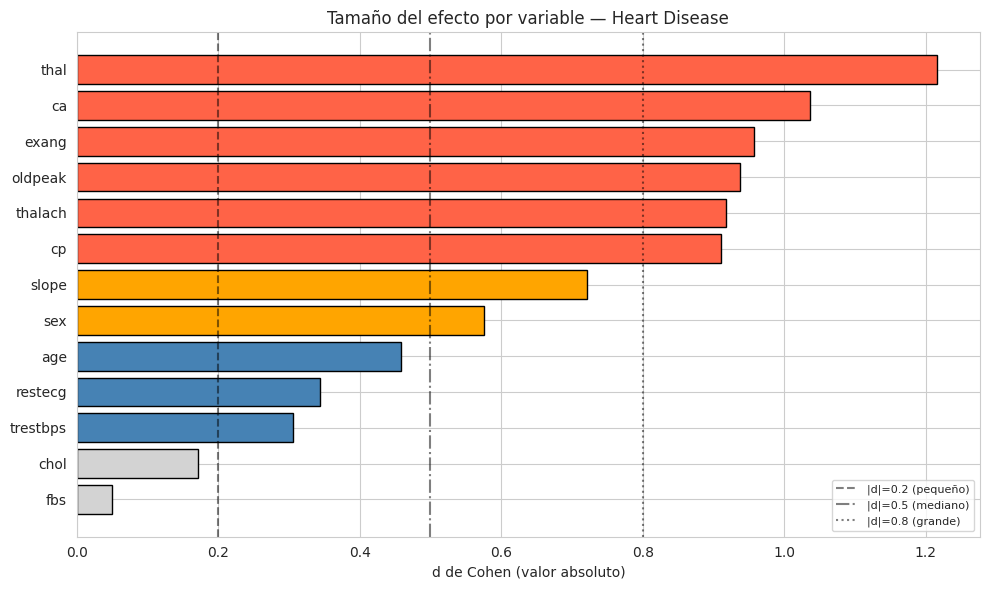

In [8]:
# TODO 6: d de Cohen por variable.
# Se calcula la diferencia estandarizada entre target=1 y target=0.
def cohen_d(df, feature_cols, group_col='target'):
    results = []
    for col in feature_cols:
        g0 = df[df[group_col] == 0][col].dropna()
        g1 = df[df[group_col] == 1][col].dropna()
        n0, n1 = len(g0), len(g1)
        v0, v1 = g0.var(ddof=1), g1.var(ddof=1)
        pooled_var = ((n0 - 1) * v0 + (n1 - 1) * v1) / (n0 + n1 - 2)
        pooled_std = np.sqrt(pooled_var) if pooled_var > 0 else np.nan
        d = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0
        abs_d = abs(d)
        efecto = ('Grande' if abs_d >= 0.8 else
                  'Mediano' if abs_d >= 0.5 else
                  'Pequeño' if abs_d >= 0.2 else 'Insignificante')
        results.append({
            'variable': col,
            'media_target_0': round(g0.mean(), 3),
            'media_target_1': round(g1.mean(), 3),
            'd_cohen': round(d, 4),
            'efecto': efecto
        })
    return pd.DataFrame(results).sort_values('d_cohen', key=abs, ascending=False)

cohen_pd = cohen_d(df_heart, FEATURE_COLS_ALL)
display(cohen_pd.reset_index(drop=True))

colors_d = {'Grande':'tomato', 'Mediano':'orange', 'Pequeño':'steelblue', 'Insignificante':'lightgrey'}
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cohen_pd['variable'][::-1], cohen_pd['d_cohen'].abs()[::-1],
        color=[colors_d[e] for e in cohen_pd['efecto'][::-1]], edgecolor='black')
for value, style, label in [(0.2, '--', 'pequeño'), (0.5, '-.', 'mediano'), (0.8, ':', 'grande')]:
    ax.axvline(value, color='black', linestyle=style, alpha=0.5,
               label=f'|d|={value} ({label})')
ax.set_xlabel('d de Cohen (valor absoluto)')
ax.set_title('Tamaño del efecto por variable — Heart Disease')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [9]:
# TODO 7: Curtosis de cada variable numérica.
# pandas.kurtosis() reporta curtosis en exceso: una normal tiene valor cercano a 0.
kurtosis_values = df_heart[FEATURE_COLS_ALL].kurtosis()

kurtosis_rows = []
for col, value in kurtosis_values.items():
    if value > 0.5:
        tipo = 'Leptocúrtica'
        interpretacion = 'colas más pesadas / mayor concentración central'
    elif value < -0.5:
        tipo = 'Platicúrtica'
        interpretacion = 'distribución más aplanada'
    else:
        tipo = 'Aprox. mesocúrtica'
        interpretacion = 'curtosis cercana a la distribución normal'
    kurtosis_rows.append({
        'variable': col,
        'curtosis': round(value, 4),
        'clasificación': tipo,
        'interpretación': interpretacion
    })

kurtosis_df = pd.DataFrame(kurtosis_rows).sort_values('curtosis', ascending=False)
display(kurtosis_df.reset_index(drop=True))


,variable,curtosis,clasificación,interpretación
0,chol,4.4917,Leptocúrtica,colas más pesadas / mayor concentración central
1,fbs,1.9597,Leptocúrtica,colas más pesadas / mayor concentración central
2,oldpeak,1.5758,Leptocúrtica,colas más pesadas / mayor concentración central
3,trestbps,0.8801,Leptocúrtica,colas más pesadas / mayor concentración central
4,ca,0.2593,Aprox. mesocúrtica,curtosis cercana a la distribución normal
5,thalach,-0.0535,Aprox. mesocúrtica,curtosis cercana a la distribución normal
6,cp,-0.4007,Aprox. mesocúrtica,curtosis cercana a la distribución normal
7,age,-0.5234,Platicúrtica,distribución más aplanada
8,slope,-0.6275,Platicúrtica,distribución más aplanada
9,sex,-1.4088,Platicúrtica,distribución más aplanada


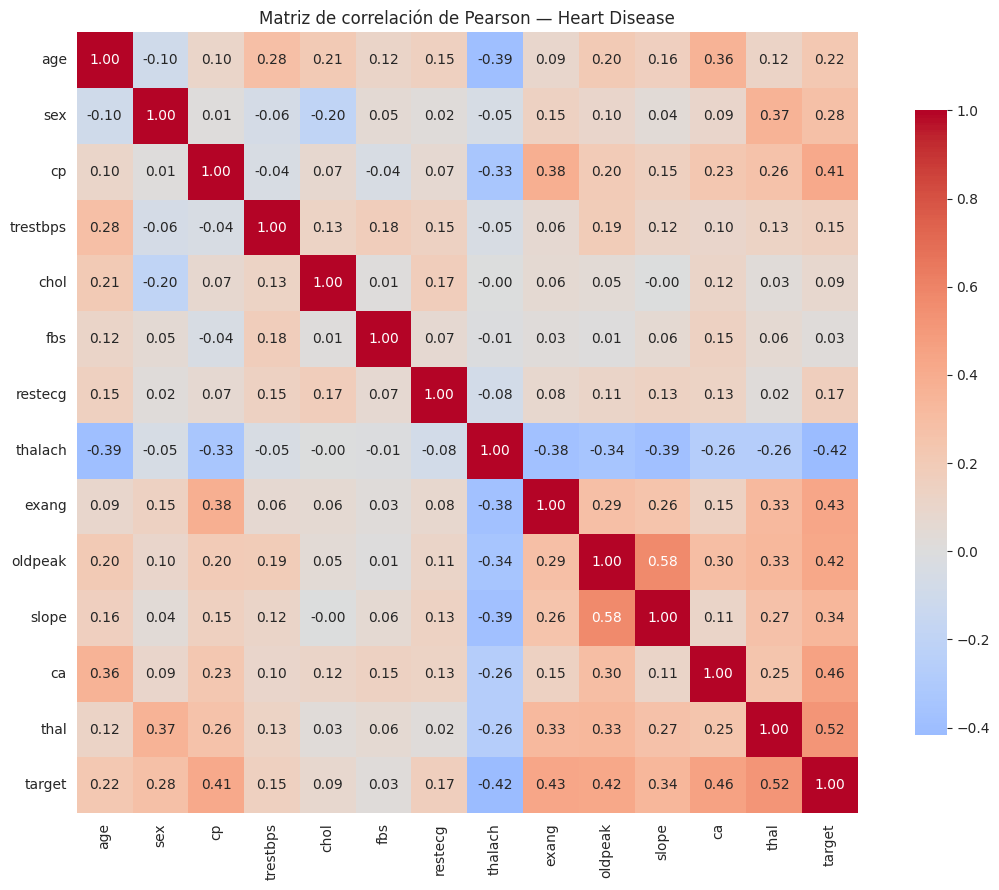


Correlación con target (ordenada por valor absoluto):
thal        0.519
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


In [10]:
# TODO 8: Mapa de calor de correlaciones de Pearson.
corr = df_heart.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación de Pearson — Heart Disease')
plt.tight_layout()
plt.show()

print('\nCorrelación con target (ordenada por valor absoluto):')
print(corr['target'].drop('target').sort_values(key=abs, ascending=False).round(3))


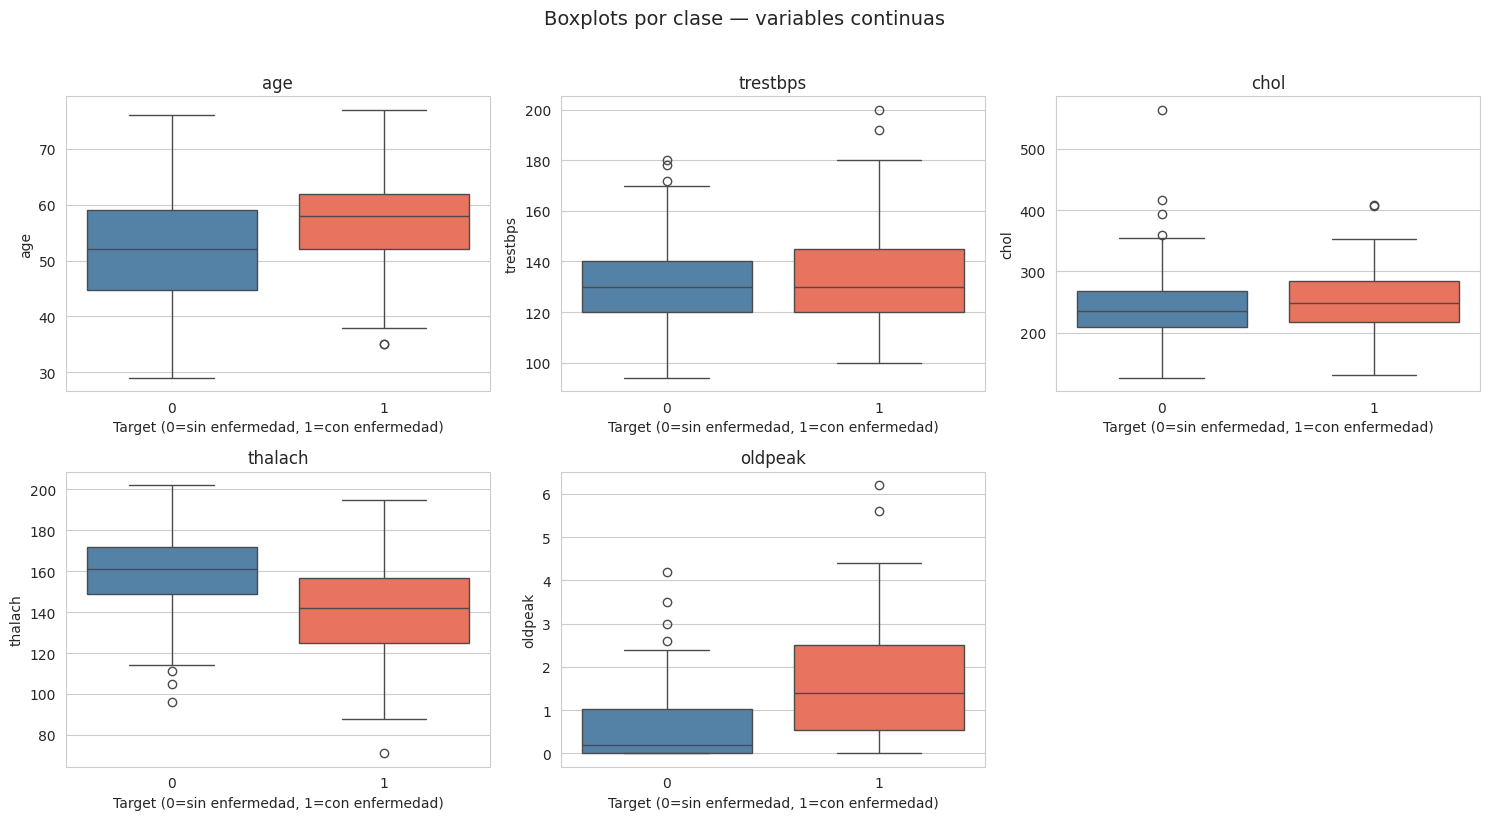

In [11]:
# TODO 9: Boxplots de variables continuas por clase para detectar posibles outliers.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, col in zip(axes, CONTINUOUS_COLS):
    sns.boxplot(x='target', y=col, data=df_heart, ax=ax, palette=['steelblue', 'tomato'])
    ax.set_title(col)
    ax.set_xlabel('Target (0=sin enfermedad, 1=con enfermedad)')

for ax in axes[len(CONTINUOUS_COLS):]:
    ax.axis('off')

plt.suptitle('Boxplots por clase — variables continuas', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Tratamiento de valores faltantes

In [12]:
# TODO 10 y 11: Comparar dos estrategias para valores faltantes.
COLS_MISSING = ['ca', 'thal']

# Estrategia A: imputación con la media usando SimpleImputer, como indica el enunciado.
imputer = SimpleImputer(strategy='mean')
df_imputed = df_heart.copy()
df_imputed[COLS_MISSING] = imputer.fit_transform(df_heart[COLS_MISSING])

# Estrategia B: eliminar las filas que tienen nulos.
df_dropna = df_heart.dropna(subset=COLS_MISSING).copy()

comparacion_missing = pd.DataFrame({
    'Estrategia': ['Imputación con media', 'dropna'],
    'Filas resultantes': [len(df_imputed), len(df_dropna)],
    'Filas eliminadas': [len(df_heart) - len(df_imputed), len(df_heart) - len(df_dropna)],
    'Nulos restantes': [df_imputed.isnull().sum().sum(), df_dropna.isnull().sum().sum()]
})
display(comparacion_missing)

print(f"\nValores imputados — ca: {imputer.statistics_[0]:.3f}, thal: {imputer.statistics_[1]:.3f}")
print('Decisión: se usa imputación con la media porque conserva los 303 registros, mientras dropna elimina filas.')


,Estrategia,Filas resultantes,Filas eliminadas,Nulos restantes
0,Imputación con media,303,0,0
1,dropna,297,6,0



Valores imputados — ca: 0.672, thal: 1.837
Decisión: se usa imputación con la media porque conserva los 303 registros, mientras dropna elimina filas.


## 4. Detección y manejo de outliers (IQR)

,variable,Q1,Q3,límite inferior,límite superior,n_outliers,porcentaje
0,trestbps,120.0,140.0,90.00,170.00,9,2.97
1,oldpeak,0.0,1.6,-2.40,4.00,5,1.65
2,chol,211.0,275.0,115.00,371.00,5,1.65
3,thalach,133.5,166.0,84.75,214.75,1,0.33
4,age,48.0,61.0,28.50,80.50,0,0.00


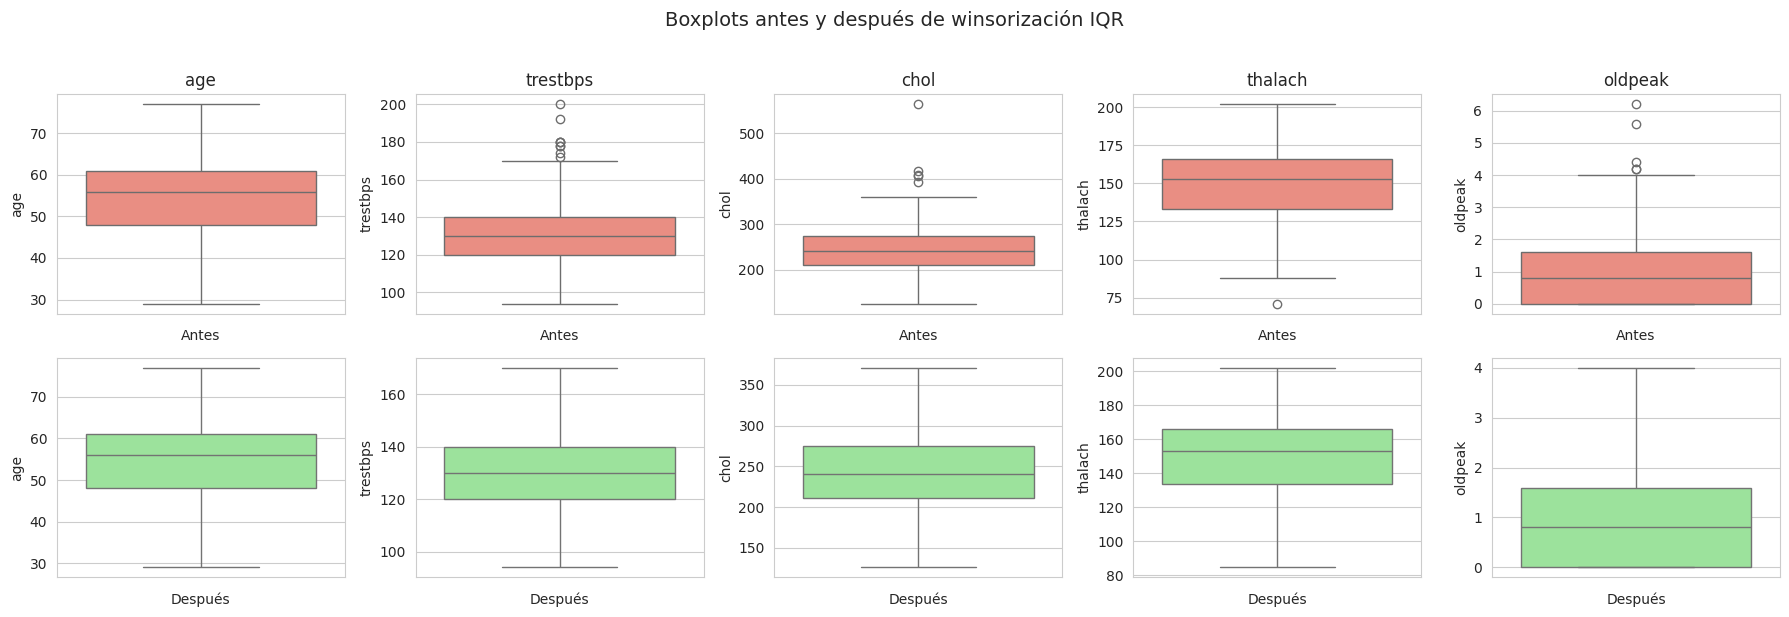

Filas antes: 303 | Filas después: 303
La winsorización conserva las filas y limita únicamente valores continuos fuera del rango IQR.


In [13]:
# TODO 12: Método IQR, porcentaje de outliers y boxplots antes/después.
# Siguiendo los ejemplos de clase, se usa winsorización (clip) en las variables continuas.
def detectar_outliers_iqr(df, columnas):
    resumen = []
    for col in columnas:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        mask = (df[col] < lim_inf) | (df[col] > lim_sup)
        resumen.append({
            'variable': col,
            'Q1': round(q1, 3),
            'Q3': round(q3, 3),
            'límite inferior': round(lim_inf, 3),
            'límite superior': round(lim_sup, 3),
            'n_outliers': int(mask.sum()),
            'porcentaje': round(100 * mask.mean(), 2)
        })
    return pd.DataFrame(resumen)

outliers_df = detectar_outliers_iqr(df_imputed, CONTINUOUS_COLS)
display(outliers_df.sort_values('n_outliers', ascending=False).reset_index(drop=True))

# Winsorización: los valores fuera de los límites IQR se recortan al límite correspondiente.
df_clean = df_imputed.copy()
for col in CONTINUOUS_COLS:
    q1 = df_imputed[col].quantile(0.25)
    q3 = df_imputed[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lim_inf, upper=lim_sup)

# Comparación visual antes y después del tratamiento.
fig, axes = plt.subplots(2, len(CONTINUOUS_COLS), figsize=(18, 6))
for j, col in enumerate(CONTINUOUS_COLS):
    sns.boxplot(y=df_imputed[col], ax=axes[0, j], color='salmon')
    axes[0, j].set_title(col)
    axes[0, j].set_xlabel('Antes')
    sns.boxplot(y=df_clean[col], ax=axes[1, j], color='lightgreen')
    axes[1, j].set_xlabel('Después')

plt.suptitle('Boxplots antes y después de winsorización IQR', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print(f'Filas antes: {len(df_imputed)} | Filas después: {len(df_clean)}')
print('La winsorización conserva las filas y limita únicamente valores continuos fuera del rango IQR.')


## 5. Preparación de features y Pipeline

In [14]:
# TODO 13 y 14: Preparación de features, split estratificado y Pipeline.
FEATURE_COLS = [c for c in df_clean.columns if c != 'target']
X = df_clean[FEATURE_COLS].copy()
y = df_clean['target'].copy()

# Split estratificado 80/20 para conservar la proporción de las clases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('\nDistribución de clases en train:')
print(pd.Series(y_train).value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')
print('\nDistribución de clases en test:')
print(pd.Series(y_test).value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

# Pipeline solicitado: SimpleImputer → StandardScaler.
# fit_transform se hace solo sobre train para evitar aprender parámetros desde test.
prep_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
X_train_s = prep_pipeline.fit_transform(X_train)
X_test_s = prep_pipeline.transform(X_test)

print('\nPipeline (SimpleImputer → StandardScaler) aplicado correctamente.')


Train: (242, 13) | Test: (61, 13)

Distribución de clases en train:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object

Distribución de clases en test:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object

Pipeline (SimpleImputer → StandardScaler) aplicado correctamente.


## 6. Modelado — Tres algoritmos de clasificación

In [15]:
# Función de evaluación reutilizable para los tres clasificadores.
# F1 se reporta macro como pide el enunciado; Precision y Recall se enfocan en la clase positiva (enfermedad).
def evaluar_modelo(nombre, y_true, y_pred, y_prob=None):
    auc_value = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    metrics = {
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1 macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC': round(auc_value, 4),
    }
    print(f"\n{nombre}")
    for key, value in metrics.items():
        if key != 'Modelo':
            print(f'  {key:<12}: {value}')
    return metrics

results_clf = {}
pred_store = {}
model_store = {}


### 6.1 Decision Tree Classifier

In [16]:
# TODO 15: Decision Tree — probar max_depth = 3, 5 y 10 y observar overfitting.
dt_rows = []
dt_candidates = {}

for depth in [3, 5, 10]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    prob_test = model.predict_proba(X_test)[:, 1]

    dt_rows.append({
        'max_depth': depth,
        'Accuracy train': accuracy_score(y_train, pred_train),
        'Accuracy test': accuracy_score(y_test, pred_test),
        'Gap train-test': accuracy_score(y_train, pred_train) - accuracy_score(y_test, pred_test),
        'F1 macro test': f1_score(y_test, pred_test, average='macro'),
        'AUC-ROC test': roc_auc_score(y_test, prob_test)
    })
    dt_candidates[depth] = model

dt_summary = pd.DataFrame(dt_rows)
display(dt_summary.round(4))

# Seleccionamos la profundidad con mayor AUC-ROC en este ejercicio comparativo.
best_dt_depth = int(dt_summary.loc[dt_summary['AUC-ROC test'].idxmax(), 'max_depth'])
dt_model = dt_candidates[best_dt_depth]
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

results_clf['Decision Tree'] = evaluar_modelo('Decision Tree', y_test, dt_pred, dt_prob)
pred_store['Decision Tree'] = {'pred': dt_pred, 'prob': dt_prob}
model_store['Decision Tree'] = dt_model

worst_gap_row = dt_summary.loc[dt_summary['Gap train-test'].idxmax()]
print(f"\nMejor profundidad por AUC-ROC: {best_dt_depth}.")
print(f"La mayor brecha train-test aparece en max_depth={int(worst_gap_row['max_depth'])}, señal de mayor sobreajuste.")


,max_depth,Accuracy train,Accuracy test,Gap train-test,F1 macro test,AUC-ROC test
0,3,0.8471,0.8525,-0.0054,0.8518,0.8544
1,5,0.9298,0.7541,0.1757,0.7538,0.7744
2,10,0.9959,0.7049,0.2909,0.7048,0.7110



Decision Tree
  Accuracy    : 0.8525
  F1 macro    : 0.8518
  Precision   : 0.8276
  Recall      : 0.8571
  AUC-ROC     : 0.8544

Mejor profundidad por AUC-ROC: 3.
La mayor brecha train-test aparece en max_depth=10, señal de mayor sobreajuste.


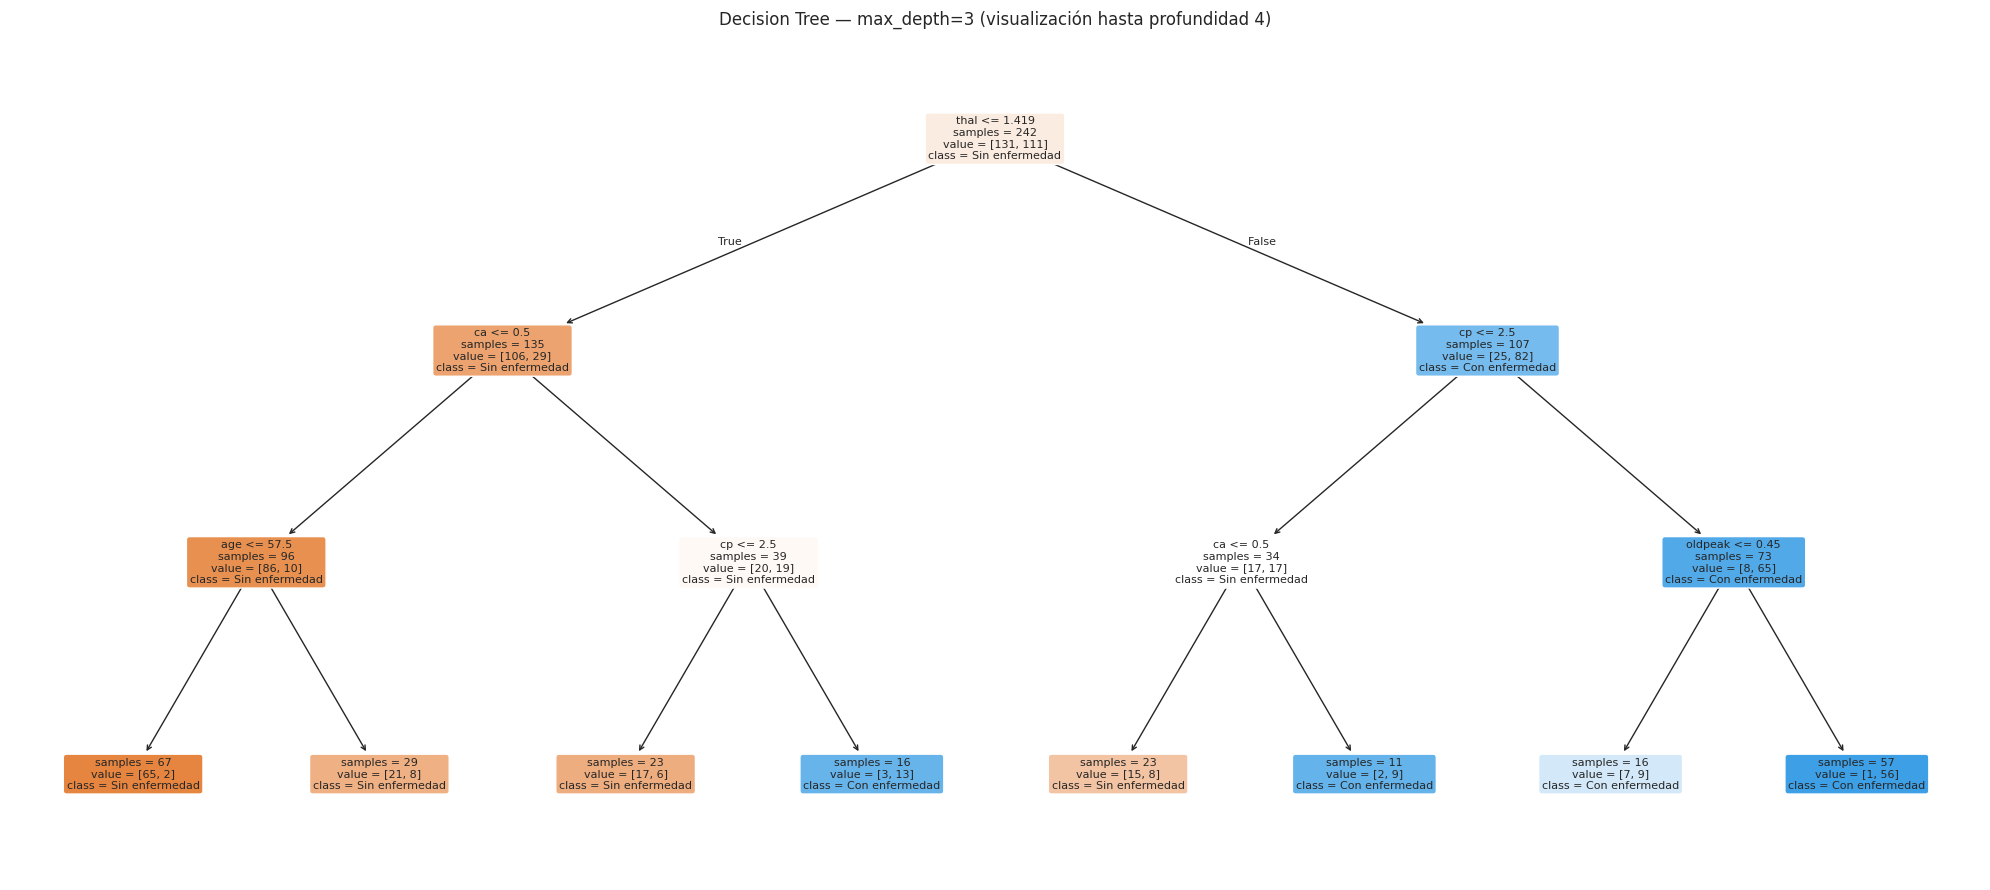

In [17]:
# TODO 16: Visualizar el Decision Tree seleccionado, limitado a profundidad visual <= 4.
plt.figure(figsize=(20, 9))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=['Sin enfermedad', 'Con enfermedad'],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8,
    impurity=False
)
plt.title(f'Decision Tree — max_depth={best_dt_depth} (visualización hasta profundidad 4)')
plt.tight_layout()
plt.show()


### 6.2 Random Forest Classifier


Random Forest
  Accuracy    : 0.8852
  F1 macro    : 0.8852
  Precision   : 0.8182
  Recall      : 0.9643
  AUC-ROC     : 0.9421


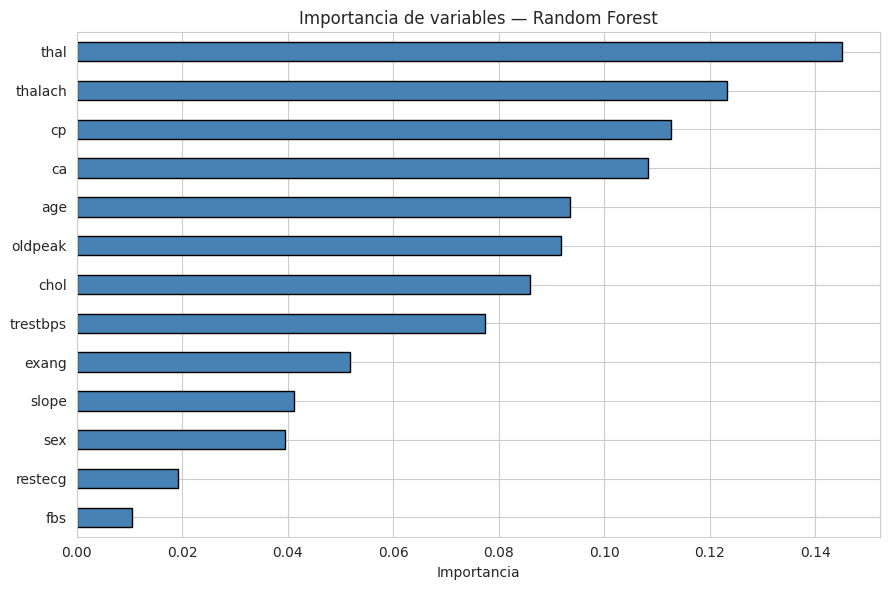


AUC Decision Tree: 0.8544
AUC Random Forest: 0.9421
El Random Forest combina muchos árboles y reduce la dependencia de una sola estructura de decisión.


In [18]:
# TODO 17: Random Forest con al menos 100 árboles e importancia de variables.
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

results_clf['Random Forest'] = evaluar_modelo('Random Forest', y_test, rf_pred, rf_prob)
pred_store['Random Forest'] = {'pred': rf_pred, 'prob': rf_prob}
model_store['Random Forest'] = rf_model

# Importancia de variables, igual que en los ejemplos vistos en clase.
importancias = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Importancia de variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(f"\nAUC Decision Tree: {results_clf['Decision Tree']['AUC-ROC']:.4f}")
print(f"AUC Random Forest: {results_clf['Random Forest']['AUC-ROC']:.4f}")
print('El Random Forest combina muchos árboles y reduce la dependencia de una sola estructura de decisión.')


### 6.3 MLP Classifier (sklearn)

In [19]:
# TODO 18: MLP — dos arquitecturas y comparación de solver adam vs sgd.
# Las redes usan los datos escalados por StandardScaler, como en los ejemplos de clase.
architectures = [(64, 32), (128, 64, 32)]
solvers = ['adam', 'sgd']
mlp_rows = []
mlp_candidates = {}

for architecture in architectures:
    for solver in solvers:
        model = MLPClassifier(
            hidden_layer_sizes=architecture,
            activation='relu',
            solver=solver,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=SEED
        )
        model.fit(X_train_s, y_train)

        pred = model.predict(X_test_s)
        prob = model.predict_proba(X_test_s)[:, 1]

        mlp_rows.append({
            'Arquitectura': str(architecture),
            'solver': solver,
            'Iteraciones': model.n_iter_,
            'Accuracy': accuracy_score(y_test, pred),
            'F1 macro': f1_score(y_test, pred, average='macro'),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'AUC-ROC': roc_auc_score(y_test, prob)
        })
        mlp_candidates[(architecture, solver)] = model

mlp_summary = pd.DataFrame(mlp_rows).sort_values('AUC-ROC', ascending=False)
display(mlp_summary.round(4).reset_index(drop=True))

best_mlp_row = mlp_summary.iloc[0]
best_arch = next(a for a in architectures if str(a) == best_mlp_row['Arquitectura'])
best_solver = best_mlp_row['solver']
mlp_model = mlp_candidates[(best_arch, best_solver)]
mlp_pred = mlp_model.predict(X_test_s)
mlp_prob = mlp_model.predict_proba(X_test_s)[:, 1]

results_clf['MLP'] = evaluar_modelo('MLP', y_test, mlp_pred, mlp_prob)
pred_store['MLP'] = {'pred': mlp_pred, 'prob': mlp_prob}
model_store['MLP'] = mlp_model

solver_comparison = mlp_summary.groupby('solver')[['AUC-ROC', 'Recall']].mean().round(4)
print('\nPromedio por solver en las dos arquitecturas:')
display(solver_comparison)
print(f'Mejor configuración MLP: arquitectura={best_arch}, solver={best_solver}.')
print('En este split, adam converge mejor que sgd con la configuración utilizada; el resultado depende también del escalado y de los hiperparámetros.')


,Arquitectura,solver,Iteraciones,Accuracy,F1 macro,Precision,Recall,AUC-ROC
0,"(128, 64, 32)",adam,29,0.8525,0.8499,0.8800,0.7857,0.9426
1,"(64, 32)",adam,19,0.8361,0.8360,0.7812,0.8929,0.9275
2,"(64, 32)",sgd,17,0.6393,0.6272,0.5682,0.8929,0.7900
3,"(128, 64, 32)",sgd,12,0.5410,0.3511,0.0000,0.0000,0.1916



MLP
  Accuracy    : 0.8525
  F1 macro    : 0.8499
  Precision   : 0.88
  Recall      : 0.7857
  AUC-ROC     : 0.9426

Promedio por solver en las dos arquitecturas:


,AUC-ROC,Recall
solver,,
adam,0.9351,0.8393
sgd,0.4908,0.4464


Mejor configuración MLP: arquitectura=(128, 64, 32), solver=adam.
En este split, adam converge mejor que sgd con la configuración utilizada; el resultado depende también del escalado y de los hiperparámetros.


## 7. Evaluación y comparación de modelos

In [20]:
# TODO 19: Tabla comparativa ordenada por AUC-ROC.
comparison_clf = pd.DataFrame(results_clf.values()).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
display(comparison_clf)

best_name = comparison_clf.iloc[0]['Modelo']
worst_name = comparison_clf.iloc[-1]['Modelo']
print(f'\nMejor modelo por AUC-ROC: {best_name}')
print(f'Menor AUC-ROC: {worst_name}')


,Modelo,Accuracy,F1 macro,Precision,Recall,AUC-ROC
0,MLP,0.8525,0.8499,0.8800,0.7857,0.9426
1,Random Forest,0.8852,0.8852,0.8182,0.9643,0.9421
2,Decision Tree,0.8525,0.8518,0.8276,0.8571,0.8544



Mejor modelo por AUC-ROC: MLP
Menor AUC-ROC: Decision Tree


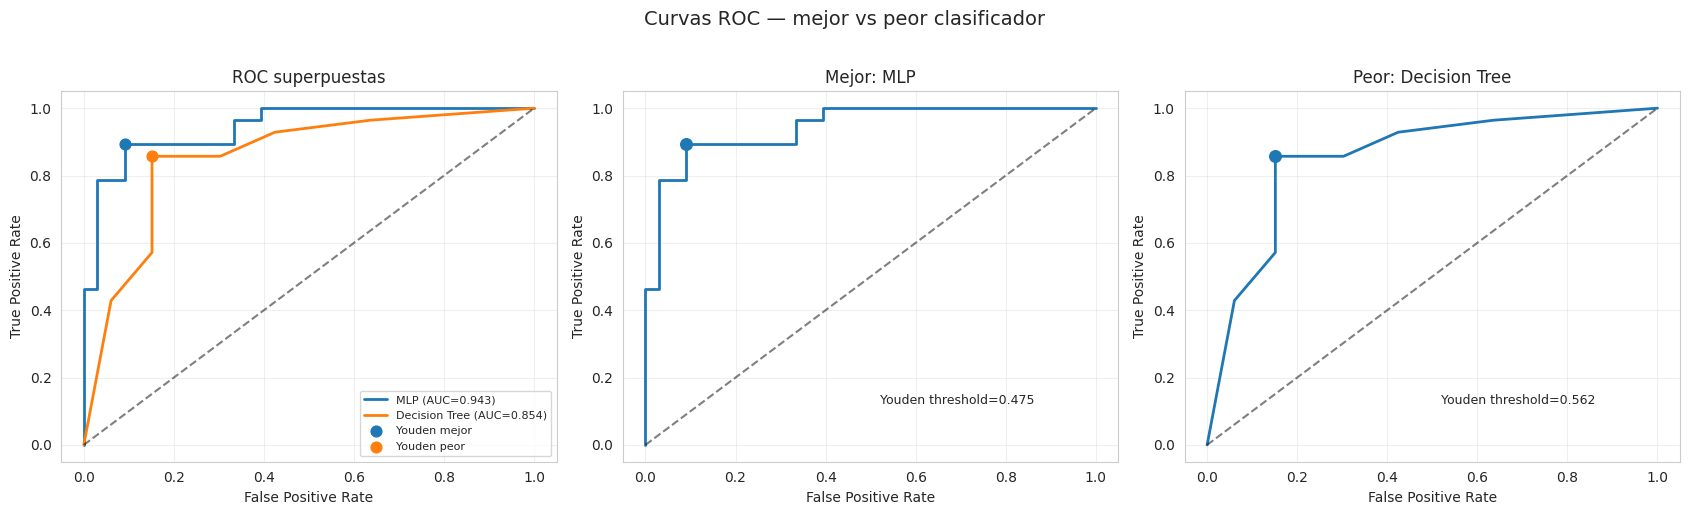

In [21]:
# TODO 20: Curvas ROC del mejor y peor modelo.
# Se muestran superpuestas y también en paneles separados; se marca el punto de Youden.
def roc_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    return fpr, tpr, thresholds, idx

best_prob = pred_store[best_name]['prob']
worst_prob = pred_store[worst_name]['prob']

fpr_b, tpr_b, thr_b, idx_b = roc_youden(y_test, best_prob)
fpr_w, tpr_w, thr_w, idx_w = roc_youden(y_test, worst_prob)
auc_b = roc_auc_score(y_test, best_prob)
auc_w = roc_auc_score(y_test, worst_prob)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: curvas superpuestas.
axes[0].plot(fpr_b, tpr_b, linewidth=2, label=f'{best_name} (AUC={auc_b:.3f})')
axes[0].plot(fpr_w, tpr_w, linewidth=2, label=f'{worst_name} (AUC={auc_w:.3f})')
axes[0].scatter(fpr_b[idx_b], tpr_b[idx_b], s=60, label='Youden mejor')
axes[0].scatter(fpr_w[idx_w], tpr_w[idx_w], s=60, label='Youden peor')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC superpuestas')
axes[0].legend(fontsize=8)

# Panel 2: mejor modelo.
axes[1].plot(fpr_b, tpr_b, linewidth=2)
axes[1].scatter(fpr_b[idx_b], tpr_b[idx_b], s=70)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title(f'Mejor: {best_name}')
axes[1].text(0.52, 0.12, f'Youden threshold={thr_b[idx_b]:.3f}', fontsize=9)

# Panel 3: peor modelo.
axes[2].plot(fpr_w, tpr_w, linewidth=2)
axes[2].scatter(fpr_w[idx_w], tpr_w[idx_w], s=70)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title(f'Peor: {worst_name}')
axes[2].text(0.52, 0.12, f'Youden threshold={thr_w[idx_w]:.3f}', fontsize=9)

for ax in axes:
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas ROC — mejor vs peor clasificador', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


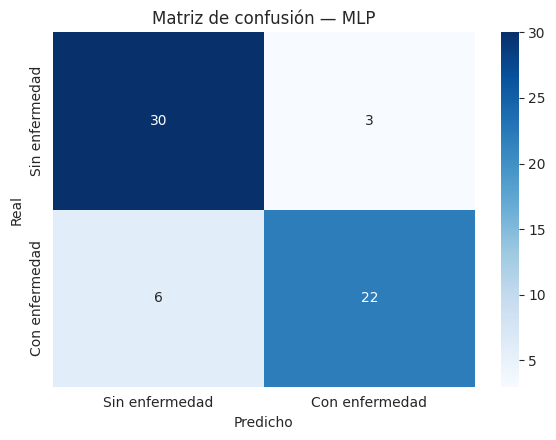

TN=30 | FP=3 | FN=6 | TP=22
Precision=0.880 | Recall=0.786

Interpretación clínica:
- Un falso negativo (FN) es especialmente costoso porque un paciente con enfermedad podría clasificarse como sano.
- Aumentar Recall ayuda a detectar más pacientes enfermos, aunque puede aumentar falsos positivos y reducir Precision.
- Por eso, en un contexto de tamizaje clínico normalmente se presta especial atención al Recall además del AUC-ROC.


In [22]:
# TODO 21: Matriz de confusión del mejor modelo y discusión clínica Precision vs Recall.
best_pred = pred_store[best_name]['pred']
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin enfermedad', 'Con enfermedad'],
            yticklabels=['Sin enfermedad', 'Con enfermedad'])
plt.title(f'Matriz de confusión — {best_name}')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
precision_best = precision_score(y_test, best_pred, zero_division=0)
recall_best = recall_score(y_test, best_pred, zero_division=0)

print(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')
print(f'Precision={precision_best:.3f} | Recall={recall_best:.3f}')
print('\nInterpretación clínica:')
print('- Un falso negativo (FN) es especialmente costoso porque un paciente con enfermedad podría clasificarse como sano.')
print('- Aumentar Recall ayuda a detectar más pacientes enfermos, aunque puede aumentar falsos positivos y reducir Precision.')
print('- Por eso, en un contexto de tamizaje clínico normalmente se presta especial atención al Recall además del AUC-ROC.')


,Fold,F1 macro
0,1,0.8165
1,2,0.7628
2,3,0.8147
3,4,0.7466
4,5,0.8653


F1 macro promedio: 0.8012 ± 0.0424
Intervalo aproximado 95%: [0.7640, 0.8383]


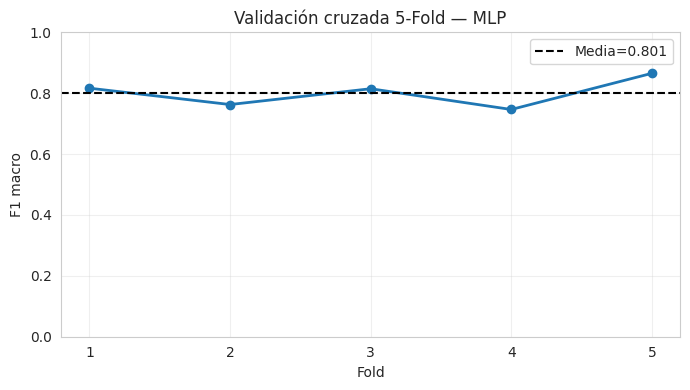

In [23]:
# TODO 22: Validación cruzada K-Fold (k=5) con cross_val_score sobre el mejor modelo.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Para CV se encapsula el preprocesamiento dentro del Pipeline para que cada fold
# aprenda su imputación y escalado únicamente con sus datos de entrenamiento.
best_estimator = clone(model_store[best_name])
cv_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', best_estimator)
])

cv_scores = cross_val_score(
    cv_pipeline,
    X,
    y,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1
)

cv_df = pd.DataFrame({
    'Fold': np.arange(1, 6),
    'F1 macro': cv_scores
})
display(cv_df.round(4))

mean_cv = cv_scores.mean()
std_cv = cv_scores.std()
ci95 = 1.96 * std_cv / np.sqrt(len(cv_scores))

print(f'F1 macro promedio: {mean_cv:.4f} ± {std_cv:.4f}')
print(f'Intervalo aproximado 95%: [{mean_cv-ci95:.4f}, {mean_cv+ci95:.4f}]')

plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), cv_scores, marker='o', linewidth=2)
plt.axhline(mean_cv, linestyle='--', color='black', label=f'Media={mean_cv:.3f}')
plt.xticks(range(1, 6))
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('F1 macro')
plt.title(f'Validación cruzada 5-Fold — {best_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
# PARTE II — CLUSTERING: MALL CUSTOMERS

## 8. EDA del dataset de clustering

In [ ]:
df_mall = df_mall_raw.copy()
# _true_cluster se guarda aparte y se elimina del DataFrame de trabajo
true_clusters = df_mall.pop('_true_cluster')
print(f'Dimensiones: {df_mall.shape}')
display(df_mall.head(5))
print('\nNulos:', df_mall.isnull().sum().to_dict())

In [ ]:
SPEND_COLS = ['Age', 'Annual_Income_k', 'Spending_Score']

# Estadísticas descriptivas
display(df_mall[SPEND_COLS].describe().round(3))

# Distribución de Genre
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
genre_vc = df_mall['Genre'].value_counts()
axes[0].bar(genre_vc.index, genre_vc.values, color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Distribución por Género')
df_mall[SPEND_COLS].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='black')
plt.suptitle('EDA — Mall Customers', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# TODO 25: Codificar Genre con LabelEncoder. Mapa de calor de correlaciones. Skewness.
# Tu código aquí:


In [ ]:
# TODO 26: Outliers IQR sobre las variables de clustering.
# Tu código aquí:


## 9. Preparación de features para clustering

In [ ]:
scaler_mall = StandardScaler()
X_mall = scaler_mall.fit_transform(df_mall_clean[SPEND_COLS])
print(f'Features escaladas: {X_mall.shape}')

# Índice de Hopkins
from sklearn.neighbors import NearestNeighbors
from random import sample as rnd_sample

def hopkins_index(X, m=None, seed=SEED):
    n, d = X.shape
    m = m or int(0.1*n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    rand_idx = rnd_sample(range(n), m)
    rng_h = np.random.default_rng(seed)
    ujd, wjd = [], []
    for j in range(m):
        u = rng_h.uniform(X.min(axis=0), X.max(axis=0), d).reshape(1,-1)
        ujd.append(nbrs.kneighbors(u, 2, return_distance=True)[0][0][1])
        wjd.append(nbrs.kneighbors(X[[rand_idx[j]]], 2, return_distance=True)[0][0][1])
    H = sum(ujd)/(sum(ujd)+sum(wjd))
    return round(float(H), 4)

H = hopkins_index(X_mall)
print(f'Índice de Hopkins: {H} ({"Apto para clustering" if H>0.7 else "Revisar estructura"})')

## 10. Selección de k — Elbow + Silhouette

In [ ]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_mall)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_mall, labels, metric='euclidean'))
    print(f'  k={k:>2}  Inercia={inertias[-1]:>12,.2f}  Silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, 'o--', color='steelblue', linewidth=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo'); axes[0].grid(alpha=0.3)

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
axes[1].plot(list(K_RANGE), sil_scores, 's--', color='tomato', linewidth=2)
axes[1].axvline(best_k, color='darkred', linestyle=':', label=f'Mejor k={best_k}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Análisis de Silhouette'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Selección de k — Mall Customers', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f'k seleccionado: {best_k}')
K_FINAL = best_k

## 11. Tres algoritmos de clustering

In [ ]:
# TODO 29: Entrenar K-Means, AgglomerativeClustering y GMM con K_FINAL.
# Para Agglomerative: probar linkage=ward/complete/average. Dendrograma.
# Para GMM: graficar BIC vs AIC. Reportar Silhouette de los tres.
# Tu código aquí:


## 12. Visualización con TSNE (PCA previo)

In [ ]:
# TODO 30: PCA (curva de varianza) + TSNE. Graficar 3 paneles comparativos.
# Tu código aquí:


In [ ]:
# COMPLETAR: ver enunciado
# Tu código aquí:


## 13. Perfilado e interpretación de clusters

In [ ]:
# Mejor algoritmo por Silhouette
best_alg = max(results_clust, key=lambda k: results_clust[k]['Silhouette'])
best_labels = {'K-Means': labels_km, 'Agglomerative': labels_agg, 'GMM': labels_gmm}[best_alg]
print(f'Mejor algoritmo: {best_alg}')

df_mall_clean['cluster'] = best_labels

# Perfil en escala original
profile = (df_mall_clean.groupby('cluster')[SPEND_COLS]
           .mean().round(2))
profile['n_clientes'] = df_mall_clean.groupby('cluster').size()
print('\nPerfil de clusters:')
display(profile)

In [ ]:
# COMPLETAR: ver enunciado
# Tu código aquí:
